# zahyou — 天体画像から目標への向きを求める

**使い方は 3 ステップだけです。**

1. **セル A** を実行 → 準備（1 回だけでよい）
2. **セル B** を実行 → ボタンで画像を選ぶ
3. **セル C** に目標を書いて実行 → すぐ下に結果と矢印が出ます

2 回目以降は **セル C だけ**を実行し直せば十分です。
別の画像に変えるときは、セル B で選び直してからセル C を実行します。

> このノートブックは `zahyou_engine.py` と**同じフォルダー**に置いてください。


In [1]:
# ==============================================================================
#  セル A : 準備 (解析エンジンの読み込み)
#
#  初回だけ次の行の # を外して実行してください (以降は # を付けたままで結構です)。
# !pip install astroquery astropy matplotlib Pillow reproject ipywidgets scipy
# ==============================================================================

import os
import sys

_ENGINE = "zahyou_engine.py"

# このノートブックと同じフォルダーを探す (VS Code / Jupyter / Colab のどれでも通るように)
_dirs = [os.getcwd()]
if "__vsc_ipynb_file__" in globals():
    _dirs.insert(0, os.path.dirname(globals()["__vsc_ipynb_file__"]))
_dirs += [p for p in sys.path[:4] if p]

_path = next((os.path.join(d, _ENGINE) for d in _dirs
              if d and os.path.exists(os.path.join(d, _ENGINE))), None)

if _path is None:
    raise SystemExit(
        f"{_ENGINE} が見つかりません。\n"
        f"  zahyou_v6.ipynb と {_ENGINE} を、同じフォルダーに置いてください。\n"
        f"  探した場所: {[d for d in _dirs if d]}")

try:
    # globals() を渡すので、セル C で書く設定 (INPUT_MODE など) もエンジンから見える
    with open(_path, encoding="utf-8") as _f:
        exec(compile(_f.read(), _path, "exec"), globals())
except ImportError as _e:
    raise SystemExit(
        f"必要なライブラリが足りません ({_e.name})。\n"
        "  このセルの 5 行目の # を外して、一度だけ実行してください。")

print(f"準備できました。  Python {sys.version.split()[0]}"
      f" / 図のフォント: {ZAHYOU_FONT or '（日本語フォントなし）'}")
print("次のセル B を実行して、画像を選んでください。")


準備できました。  Python 3.13.3 / 図のフォント: Yu Gothic
次のセル B を実行して、画像を選んでください。


In [2]:
# ==============================================================================
#  セル B : 画像を選ぶ
# ==============================================================================

pick_image()


画像を選んだら、次のセル C を実行してください。
※ ボタンを使わず、セル C の IMAGE_PATH にパスを直接書いても構いません。


  zahyou v6   Capture_00001 00_10_33.fits
読み込み : 968 x 548 画素   [FITS HDU[0] (548, 968) uint8]

星を検出しています...
  - ホットピクセル 39 画素を平滑化
  - 焼き込みオーバーレイとみられる 16456 画素をマスク
  - マスク合計 16456 / 530464 画素
  - 星を 17 個検出 (しきい値 8σ / 典型 FWHM 2.6 px)

🌍 オンライン環境で実行します。

'UCAC4 660-021020' の座標を調べています...
  - 名前解決 (SIMBAD/Sesame): 04h07m38.878s +41d59m10.593s
  - Gaia DR3 で精密化: RA=61.911992° Dec=41.986262° (G=13.06, 候補 1 個中で最も近い星)

[オンライン] nova.astrometry.net に問い合わせます (最大 120 秒)
  - 画素スケールの手がかり: 1.462″/px (前回この機材で解いたときの実測値)
  - 目標の方向 (半径 5°) を手がかりにします。
  - 検出した 17 個の星の位置だけを送ります。


Set MJD-AVG to 60937.632330 from DATE-AVG.
Set MJD-END to 60937.632330 from DATE-END'. [astropy.wcs.wcs]


✅ オンライン解析に成功しました。

  解析結果
  画像中心      : 04h07m33.94s +41d57m53.14s
                  (RA 61.891414°, Dec 41.964760°)
  画素スケール  : 1.4616 秒角/px
  視野          : 23.58′ x 13.35′
  画面上方向    : 位置角 152.87°(北から東回り)
  パリティ      : 正 (鏡像なし)
  解いた方法    : オンライン (nova.astrometry.net)
  所要時間      : 9.5 秒
  逆算した焦点距離: 819 mm

  目標は画面内です: ピクセル (425.8, 243.5)
  目標そのものは、この検出しきい値では拾えていません (暗い星なら正常です)。


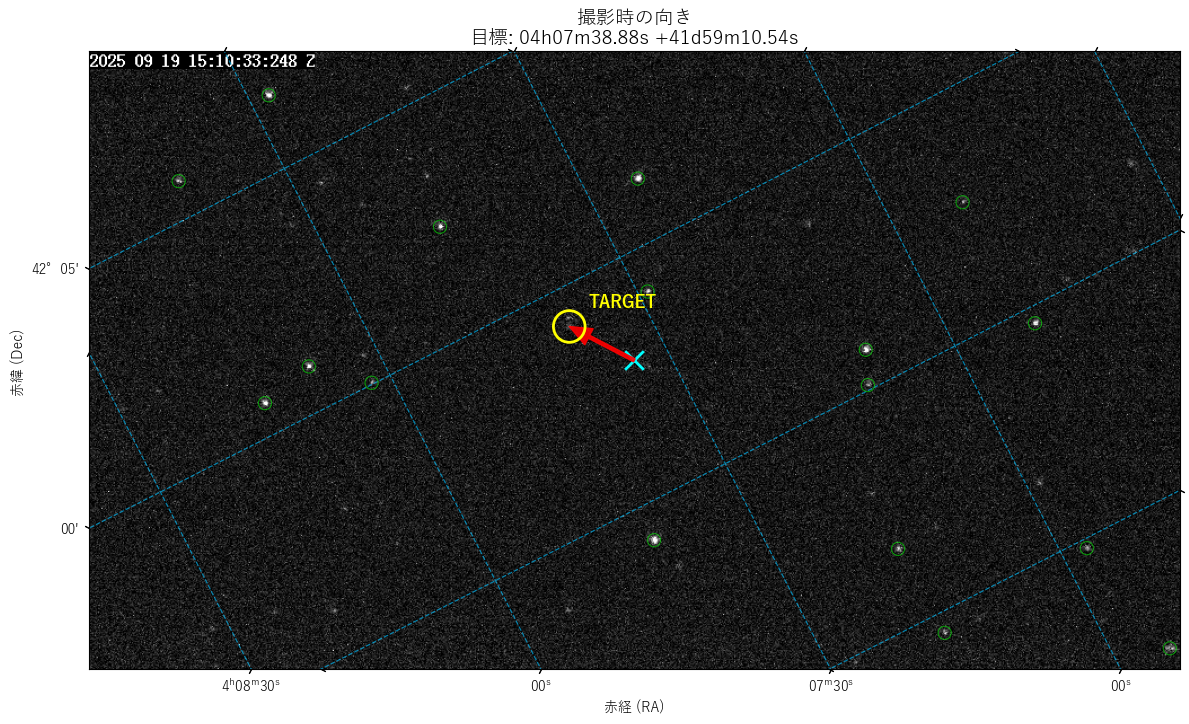


  画像中心から目標までのずれ
    全角距離      : 1.583′  (95.0″)
    赤経(RA) 方向 : 0.918′ 東へ
    赤緯(Dec)方向 : 1.290′ 北へ


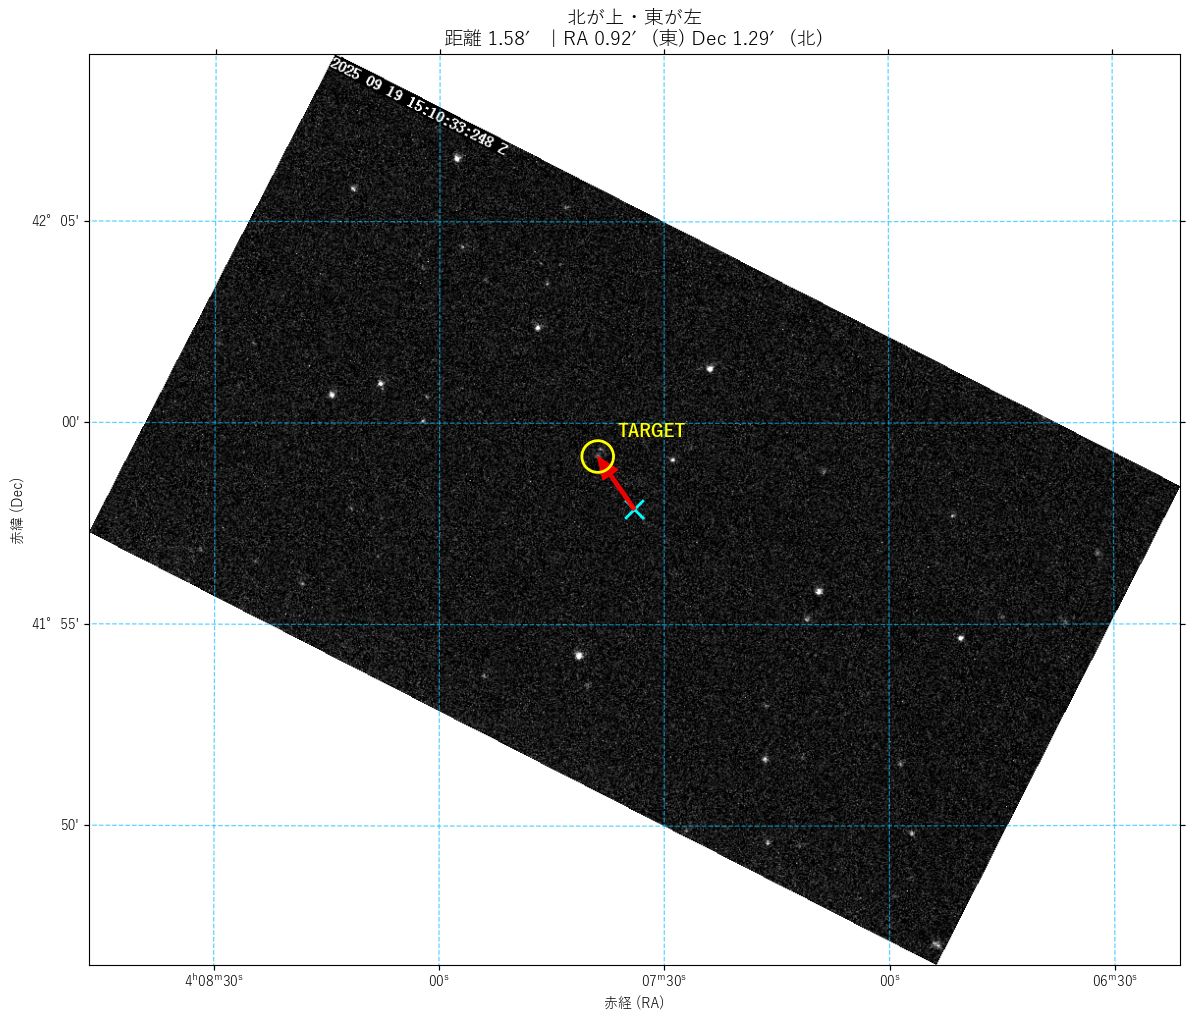

In [5]:
# ==============================================================================
#  セル C : ユーザー設定と実行
#
#  ★ 書き換えるのはこのセルだけです。実行すると、すぐ下に結果が出ます。
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. 目標の指定方法  'STAR_NAME'(天体名) か 'COORDS'(赤経赤緯)
#    ※ 天体名はオンラインで一度引ければ記憶するので、次からはオフラインでも使えます
INPUT_MODE = 'STAR_NAME'

# 1a. 天体名で指定する場合 (INPUT_MODE = 'STAR_NAME')
TARGET_STAR_NAME = 'UCAC4 660-021020'

# 1b. 赤経赤緯で指定する場合 (INPUT_MODE = 'COORDS')
RA_INPUT_STR = "04h 07m 38.877s"
DEC_INPUT_STR = "+41d 59m 10.512s"

# ------------------------------------------------------------------------------
# 2. 望遠鏡の焦点距離 [mm]
#    分かっているなら必ず入れてください。画角が確定するので、
#    オフライン解析が桁違いに速く・確実になります。分からなければ None。
FOCAL_LENGTH_MM = None

# ------------------------------------------------------------------------------
# 3. 解析の方法  'AUTO'(自動) / 'ONLINE'(ネットのみ) / 'OFFLINE'(WSL のみ)
SOLVE_MODE = 'AUTO'

ONLINE_TIMEOUT = 120      # オンライン解析の打ち切り時間 [秒]
OFFLINE_TIMEOUT = 300     # オフライン(WSL)解析にかけてよい合計時間 [秒]

# 目標のだいたいの方向を手がかりに使う (向けている先を探すので圧倒的に速い)
USE_TARGET_AS_HINT = True
SEARCH_RADIUS_DEG = 5.0   # 導入誤差がもっと大きいなら広げる

# ------------------------------------------------------------------------------
# 4. その他
IGNORE_EXISTING_WCS = True    # 画像に既に入っている座標情報を無視して解き直す
SHOW_DETECTED_SOURCES = True  # 検出した星に緑の丸を重ねる
IMAGE_PATH = None             # ボタンを使わずパスを直接指定するとき

# 5. Astrometry.net の API キー (オンライン解析用)
API_KEY = os.environ.get("ASTROMETRY_API_KEY", "axvhxwfkvnzreobn")
# ==============================================================================

_result_wcs = run()
